# YOLO Test Set Visualization

Notebook ini menjalankan inference pada 37 gambar test set Roboflow format YOLO menggunakan model `yolov8n.pt` dan `yolo26n.pt`/`yolov26n.pt` dari direktori kerja.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Setup environment
import os
import sys
import shutil
import zipfile
import subprocess
import urllib.request
from pathlib import Path

import numpy as np
import yaml
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def ensure_ultralytics(min_version="8.4.0"):
    try:
        import ultralytics
        from packaging.version import Version
        if Version(ultralytics.__version__) >= Version(min_version):
            return
        print(f"Ultralytics {ultralytics.__version__} terlalu lama; upgrade ke >= {min_version}...")
    except Exception:
        print("Ultralytics belum tersedia; install sekarang...")

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "ultralytics"])

ensure_ultralytics()
from ultralytics import YOLO
import ultralytics
print(f"Ultralytics: {ultralytics.__version__}")

plt.rcParams["figure.facecolor"] = "white"

# Compatibility for older Ultralytics checkpoints on PyTorch 2.6+.
# Use only for local/trusted .pt files.
import torch
_original_torch_load = torch.load
def torch_load_compatible(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _original_torch_load(*args, **kwargs)
torch.load = torch_load_compatible


print(f"Python: {sys.version.split()[0]}")
print("Ultralytics YOLO siap digunakan")

Ultralytics belum tersedia; install sekarang...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.62
Python: 3.12.13
Ultralytics YOLO siap digunakan


In [ ]:
ROBOFLOW_LINK = "https://app.roboflow.com/ds/XMFWM8OwUN?key=tY0B1mvERs"
DATASET_DIR = Path("data/roboflow_yolo")
ZIP_PATH = Path("roboflow_yolo_dataset.zip")
OUTPUT_DIR = Path("outputs_yolo/test_visualizations")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_CANDIDATES = {
    "YOLOv8n": [
        Path("yolov8n.pt"),
        Path("./yolov8n.pt"),
        Path("/content/yolov8n.pt"),
        Path("/content/drive/MyDrive/Best Model/yolov8n.pt"),
    ],
    "YOLOv26n": [
        Path("yolov26n.pt"),
        Path("./yolov26n.pt"),
        Path("yolo26n.pt"),
        Path("./yolo26n.pt"),
        Path("/content/yolov26n.pt"),
        Path("/content/yolo26n.pt"),
        Path("/content/drive/MyDrive/Best Model/yolov26n.pt"),
        Path("/content/drive/MyDrive/Best Model/yolo26n.pt"),
    ],
}

VISUALIZATION_COUNT = 37
CONF_THRESHOLD = 0.25
GT_COLOR = "deepskyblue"
PRED_COLOR = "lime"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print(f"Dataset directory: {DATASET_DIR.resolve()}")
print(f"Output directory : {OUTPUT_DIR.resolve()}")

Dataset directory: /content/data/roboflow_yolo
Output directory : /content/outputs_yolo/test_visualizations


In [ ]:
# Download dan ekstrak dataset Roboflow format YOLO

def download_file(url, destination):
    if destination.exists():
        destination.unlink()

    print("Mencoba download dengan urllib...")
    try:
        urllib.request.urlretrieve(url, destination)
    except Exception as exc:
        print(f"urllib gagal: {exc}")
        print("Mencoba download dengan curl...")
        result = subprocess.run(
            ["curl", "-L", url, "-o", str(destination)],
            capture_output=True,
            text=True,
        )
        if result.returncode != 0:
            raise RuntimeError(result.stderr or "curl gagal mengunduh dataset")

    if not destination.exists() or destination.stat().st_size < 100_000:
        raise RuntimeError("File dataset terlalu kecil atau tidak berhasil diunduh. Cek ulang link Roboflow.")


def has_yolo_dataset(root):
    return (root / "data.yaml").exists() and any((root / split / "images").exists() for split in ["test", "valid", "train"])

if not has_yolo_dataset(DATASET_DIR):
    DATASET_DIR.mkdir(parents=True, exist_ok=True)
    download_file(ROBOFLOW_LINK, ZIP_PATH)
    print(f"OK Dataset terunduh: {ZIP_PATH} ({ZIP_PATH.stat().st_size / 1024 / 1024:.2f} MB)")

    if DATASET_DIR.exists():
        shutil.rmtree(DATASET_DIR)
    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATASET_DIR)
    ZIP_PATH.unlink(missing_ok=True)
    print(f"OK Dataset diekstrak ke: {DATASET_DIR}")
else:
    print(f"OK Dataset sudah ada: {DATASET_DIR}")

print("\nIsi dataset:")
for item in sorted(DATASET_DIR.iterdir()):
    print("-", item.name)

Mencoba download dengan urllib...
OK Dataset terunduh: roboflow_yolo_dataset.zip (7.02 MB)
OK Dataset diekstrak ke: data/roboflow_yolo

Isi dataset:
- README.dataset.txt
- README.roboflow.txt
- data.yaml
- train


In [ ]:
# Resolve struktur dataset YOLO dan siapkan test split

def find_data_yaml(root):
    candidates = [root / "data.yaml"] + sorted(root.rglob("data.yaml"))
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"data.yaml tidak ditemukan di {root}")


def normalize_split_path(dataset_root, split_value):
    if split_value is None:
        return None
    split_path = Path(split_value)
    if split_path.is_absolute():
        return split_path
    return (dataset_root / split_path).resolve()


def resolve_images_dir(split_path):
    if split_path is None:
        return None
    split_path = Path(split_path)
    if split_path.name == "images" and split_path.exists():
        return split_path
    images_dir = split_path / "images"
    if images_dir.exists():
        return images_dir
    if split_path.exists():
        return split_path
    return None


def list_images(images_dir):
    if images_dir is None or not images_dir.exists():
        return []
    return sorted([p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS])


def copy_image_and_label(image_path, destination_images_dir):
    destination_labels_dir = destination_images_dir.parent / "labels"
    destination_images_dir.mkdir(parents=True, exist_ok=True)
    destination_labels_dir.mkdir(parents=True, exist_ok=True)

    shutil.copy2(image_path, destination_images_dir / image_path.name)
    source_label = image_path.parent.parent / "labels" / f"{image_path.stem}.txt"
    if source_label.exists():
        shutil.copy2(source_label, destination_labels_dir / source_label.name)


def build_test_split_from_train(train_images_dir, split_root, test_size=0.15, random_state=42):
    all_images = list_images(train_images_dir)
    if not all_images:
        raise ValueError(f"Tidak ada gambar train untuk membuat test split: {train_images_dir}")

    test_count = max(1, int(np.ceil(len(all_images) * test_size)))
    rng = np.random.default_rng(random_state)
    selected_indices = sorted(rng.choice(len(all_images), size=test_count, replace=False).tolist())
    selected_images = [all_images[idx] for idx in selected_indices]

    if split_root.exists():
        shutil.rmtree(split_root)
    test_images_dir = split_root / "test" / "images"
    for image_path in selected_images:
        copy_image_and_label(image_path, test_images_dir)

    return test_images_dir

DATA_YAML = find_data_yaml(DATASET_DIR)
DATA_ROOT = DATA_YAML.parent
with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

names = data_config.get("names", [])
if isinstance(names, dict):
    CLASS_NAMES = [names[i] for i in sorted(names)]
else:
    CLASS_NAMES = list(names)

explicit_test_candidates = [
    normalize_split_path(DATA_ROOT, data_config.get("test")),
    DATA_ROOT / "test",
]

TEST_IMAGES_DIR = None
for split_path in explicit_test_candidates:
    images_dir = resolve_images_dir(split_path)
    if list_images(images_dir):
        TEST_IMAGES_DIR = images_dir
        print("OK Menggunakan test split bawaan dataset")
        break

if TEST_IMAGES_DIR is None:
    train_candidates = [
        normalize_split_path(DATA_ROOT, data_config.get("train")),
        DATA_ROOT / "train",
    ]
    TRAIN_IMAGES_DIR = None
    for split_path in train_candidates:
        images_dir = resolve_images_dir(split_path)
        if list_images(images_dir):
            TRAIN_IMAGES_DIR = images_dir
            break

    if TRAIN_IMAGES_DIR is None:
        raise FileNotFoundError("Folder train/images tidak ditemukan untuk membuat test split.")

    TEST_SPLIT_ROOT = DATASET_DIR / "generated_test_split"
    TEST_IMAGES_DIR = build_test_split_from_train(TRAIN_IMAGES_DIR, TEST_SPLIT_ROOT, test_size=0.15, random_state=42)
    print("OK Dataset tidak memiliki folder test; dibuat test split 15% dari train")

TEST_LABELS_DIR = TEST_IMAGES_DIR.parent / "labels"
TEST_IMAGES = list_images(TEST_IMAGES_DIR)
SELECTED_IMAGES = TEST_IMAGES[:min(VISUALIZATION_COUNT, len(TEST_IMAGES))]

print(f"data.yaml       : {DATA_YAML}")
print(f"Jumlah kelas    : {len(CLASS_NAMES)}")
print(f"Images directory: {TEST_IMAGES_DIR}")
print(f"Labels directory: {TEST_LABELS_DIR}")
print(f"Total test image: {len(TEST_IMAGES)}")
print(f"Dipakai         : {len(SELECTED_IMAGES)} gambar")

if len(SELECTED_IMAGES) == 0:
    raise ValueError("Tidak ada gambar test yang bisa divisualisasikan.")

OK Dataset tidak memiliki folder test; dibuat test split 15% dari train
data.yaml       : data/roboflow_yolo/data.yaml
Jumlah kelas    : 26
Images directory: data/roboflow_yolo/generated_test_split/test/images
Labels directory: data/roboflow_yolo/generated_test_split/test/labels
Total test image: 37
Dipakai         : 37 gambar


In [ ]:
# Load model YOLO lokal

def resolve_model_path(candidates, model_name):
    for candidate in candidates:
        if candidate.exists():
            return candidate

    search_roots = [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive/Best Model")]
    wanted = {p.name.lower() for p in candidates}
    for root in search_roots:
        if not root.exists():
            continue
        for path in root.rglob("*.pt"):
            normalized_name = path.name.lower()
            if normalized_name in wanted:
                return path
            if model_name.lower() == "yolov8n" and "yolov8n" in normalized_name:
                return path
            if model_name.lower() == "yolov26n" and ("yolov26n" in normalized_name or "yolo26n" in normalized_name):
                return path

    raise FileNotFoundError(f"Weight untuk {model_name} tidak ditemukan. Kandidat: {candidates}")

models = []
for model_name, candidates in MODEL_CANDIDATES.items():
    weight_path = resolve_model_path(candidates, model_name)
    print(f"Loading {model_name}: {weight_path}")
    model = YOLO(str(weight_path))
    models.append({"name": model_name, "path": weight_path, "model": model})

print(f"\nOK {len(models)} model berhasil dimuat")

Loading YOLOv8n: /content/drive/MyDrive/Best Model/yolov8n.pt
Loading YOLOv26n: /content/drive/MyDrive/Best Model/yolov26n.pt

OK 2 model berhasil dimuat


In [ ]:
# Helper visualisasi ground truth YOLO dan prediksi

def class_name(class_id):
    class_id = int(class_id)
    if 0 <= class_id < len(CLASS_NAMES):
        return CLASS_NAMES[class_id]
    return str(class_id)


def read_yolo_labels(label_path, image_width, image_height):
    boxes = []
    if not label_path.exists():
        return boxes

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            class_id, x_center, y_center, width, height = map(float, parts[:5])
            x1 = (x_center - width / 2) * image_width
            y1 = (y_center - height / 2) * image_height
            x2 = (x_center + width / 2) * image_width
            y2 = (y_center + height / 2) * image_height
            boxes.append({"box": [x1, y1, x2, y2], "class_id": int(class_id), "score": None})
    return boxes


def draw_detections(ax, image, detections, title, color, threshold=0.0):
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(title, fontsize=11)

    for det in detections:
        score = det.get("score")
        if score is not None and score < threshold:
            continue

        x1, y1, x2, y2 = det["box"]

        label_text = class_name(det["class_id"])
        if score is not None:
            label_text = f'{label_text} {score:.2f}'

        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor=color,
            fill=False,
        )
        ax.add_patch(rect)
        ax.text(
            x1,
            max(0, y1 - 4),
            label_text,
            color="white",
            fontsize=9,
            bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor="none"),
        )


def predict_image(model, image_path, conf=CONF_THRESHOLD):
    results = model.predict(source=str(image_path), conf=conf, verbose=False)
    if not results or results[0].boxes is None:
        return []

    boxes = results[0].boxes
    xyxy = boxes.xyxy.cpu().numpy()
    classes = boxes.cls.cpu().numpy().astype(int)
    scores = boxes.conf.cpu().numpy()

    return [
        {"box": box.tolist(), "class_id": int(cls), "score": float(score)}
        for box, cls, score in zip(xyxy, classes, scores)
    ]

In [ ]:
import matplotlib.pyplot as plt

# Jalankan inference dan simpan visualisasi untuk setiap gambar test set
individual_dir = OUTPUT_DIR / "individual"
individual_dir.mkdir(parents=True, exist_ok=True)

print('\n' + '=' * 90)
print('RUNNING YOLO TEST SET INFERENCE & VISUALIZATION PER IMAGE')
print('=' * 90)
print(f"Total gambar divisualisasikan: {len(SELECTED_IMAGES)}")
print(f"Warna GT   : {GT_COLOR}")
print(f"Warna pred : {PRED_COLOR}")

for idx, image_path in enumerate(SELECTED_IMAGES):
    image = Image.open(image_path).convert("RGB")
    width, height = image.size
    label_path = TEST_LABELS_DIR / f"{image_path.stem}.txt"
    gt_detections = read_yolo_labels(label_path, width, height)

    rows = 1
    cols = len(models) + 1
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), squeeze=False)

    draw_detections(
        axes[0, 0],
        image,
        gt_detections,
        title=f"Test sample {idx + 1} - Ground Truth ({len(gt_detections)})",
        color=GT_COLOR,
        threshold=0.0,
    )

    for col, spec in enumerate(models, start=1):
        predictions = predict_image(spec["model"], image_path)
        draw_detections(
            axes[0, col],
            image,
            predictions,
            title=f"{spec['name']} - {len(predictions)} deteksi",
            color=PRED_COLOR,
            threshold=CONF_THRESHOLD,
        )

    plt.tight_layout()
    # Save each image individually
    individual_image_path = individual_dir / f"test_{idx + 1}.png"
    plt.savefig(individual_image_path, dpi=200, bbox_inches="tight")
    plt.close(fig) # Close the figure to free up memory
    print(f"\n✓ Visualisasi gambar {idx + 1} disimpan ke: {individual_image_path}")

print('\n✓ Inference selesai untuk semua model pada data test terpilih')


RUNNING YOLO TEST SET INFERENCE & VISUALIZATION PER IMAGE
Total gambar divisualisasikan: 37
Warna GT   : deepskyblue
Warna pred : lime

✓ Visualisasi gambar 1 disimpan ke: outputs_yolo/test_visualizations/individual/test_1.png

✓ Visualisasi gambar 2 disimpan ke: outputs_yolo/test_visualizations/individual/test_2.png

✓ Visualisasi gambar 3 disimpan ke: outputs_yolo/test_visualizations/individual/test_3.png

✓ Visualisasi gambar 4 disimpan ke: outputs_yolo/test_visualizations/individual/test_4.png

✓ Visualisasi gambar 5 disimpan ke: outputs_yolo/test_visualizations/individual/test_5.png

✓ Visualisasi gambar 6 disimpan ke: outputs_yolo/test_visualizations/individual/test_6.png

✓ Visualisasi gambar 7 disimpan ke: outputs_yolo/test_visualizations/individual/test_7.png

✓ Visualisasi gambar 8 disimpan ke: outputs_yolo/test_visualizations/individual/test_8.png

✓ Visualisasi gambar 9 disimpan ke: outputs_yolo/test_visualizations/individual/test_9.png

✓ Visualisasi gambar 10 disimpan ke


Menampilkan visualisasi dari: outputs_yolo/test_visualizations/individual


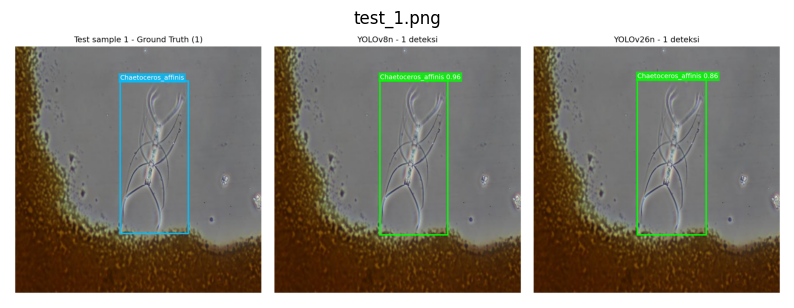

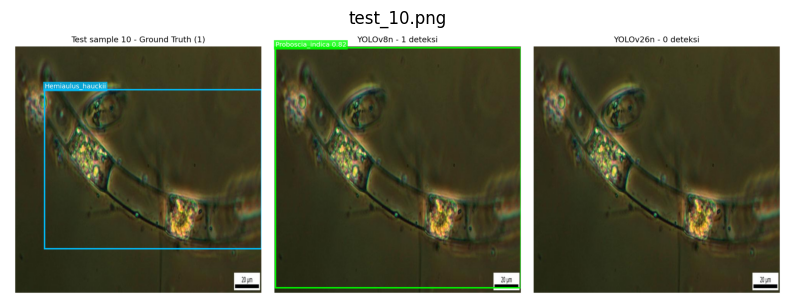

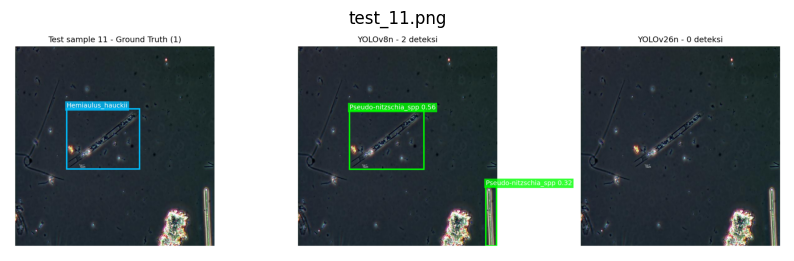

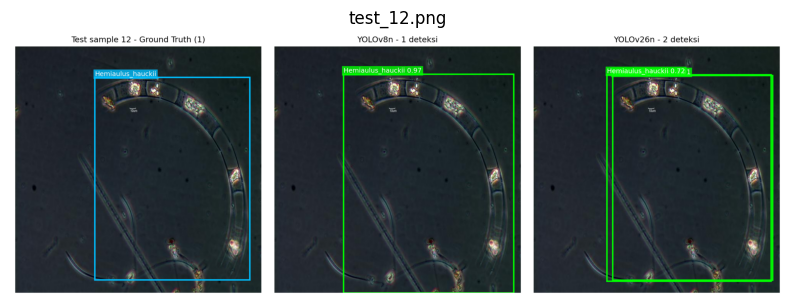

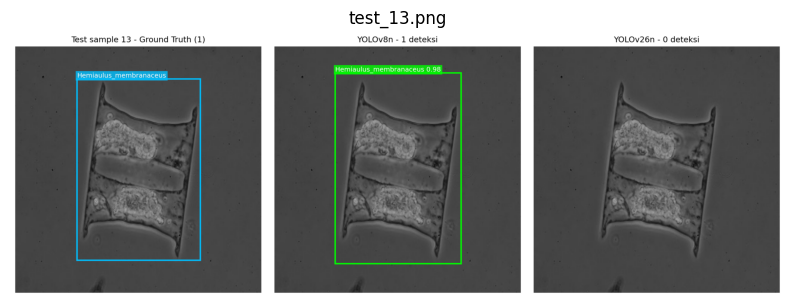

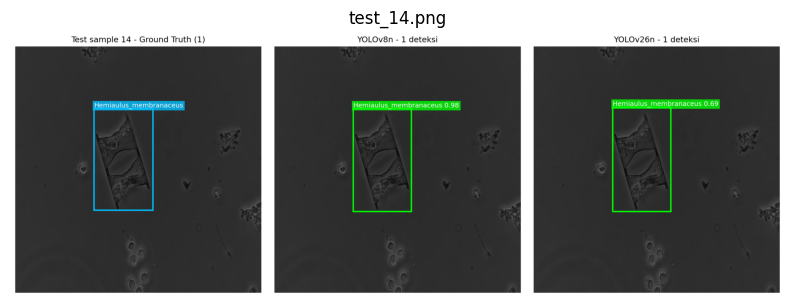

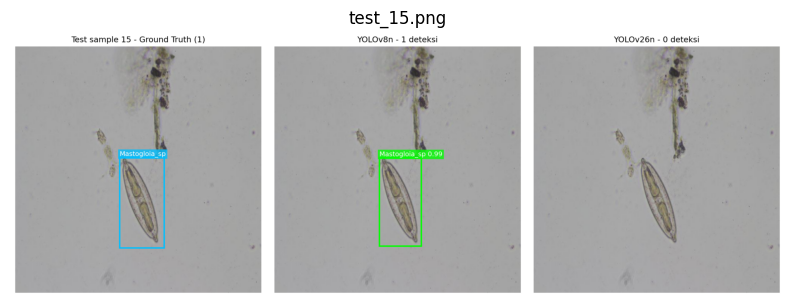

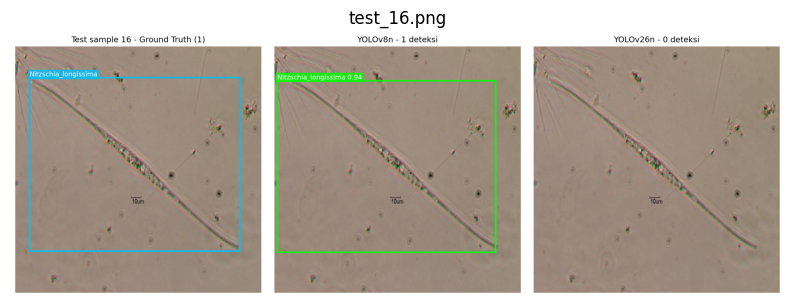

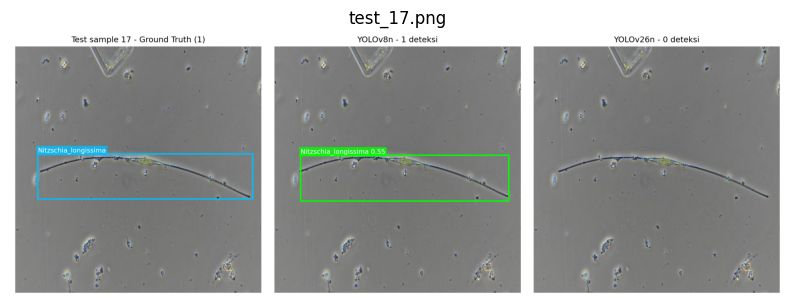

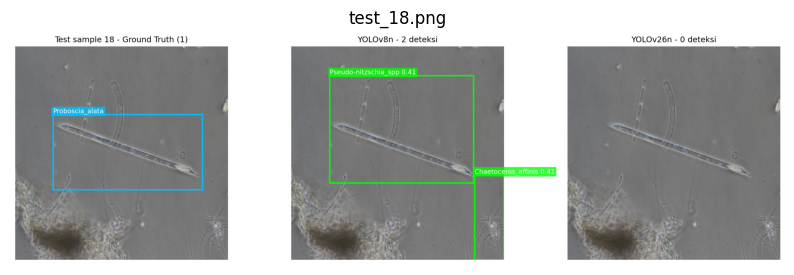

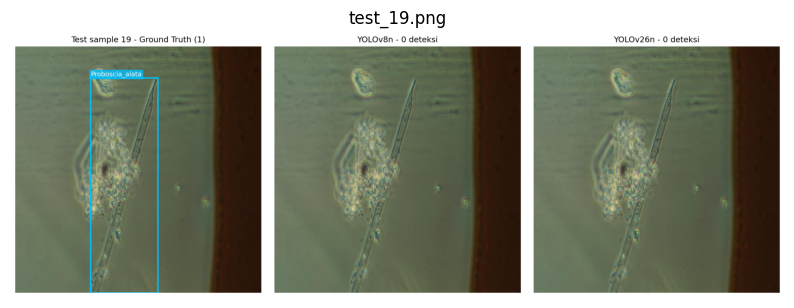

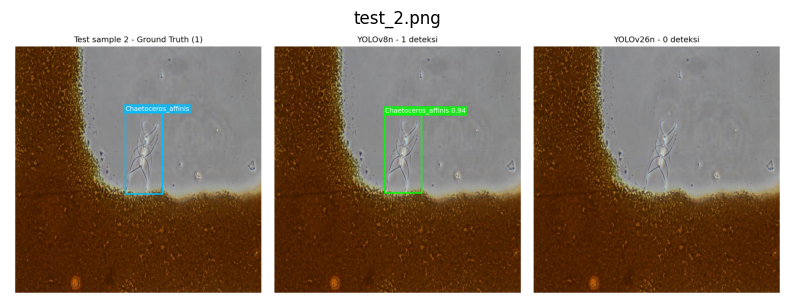

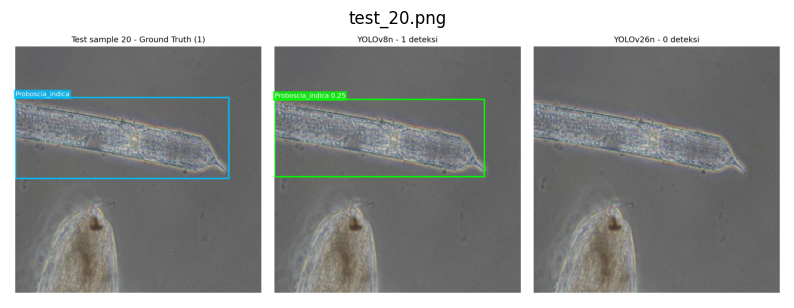

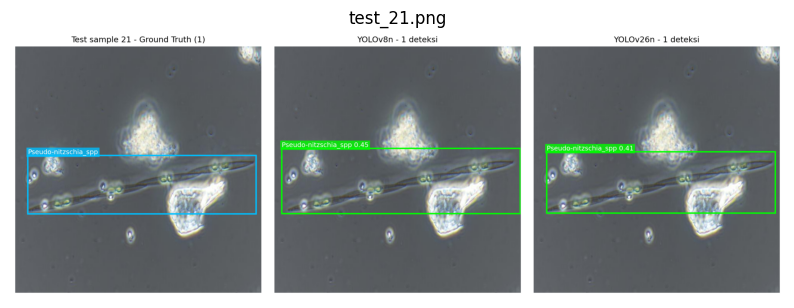

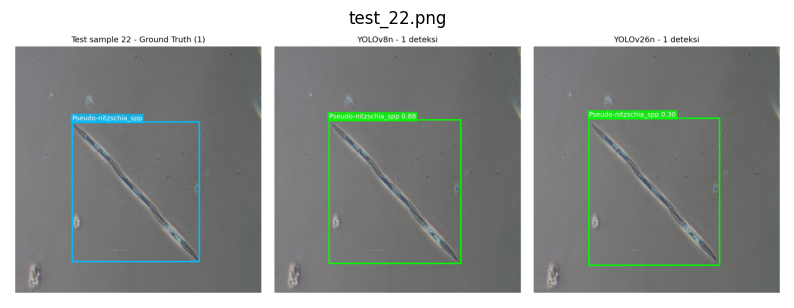

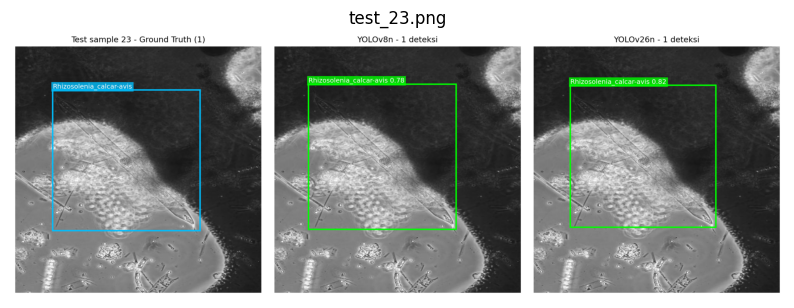

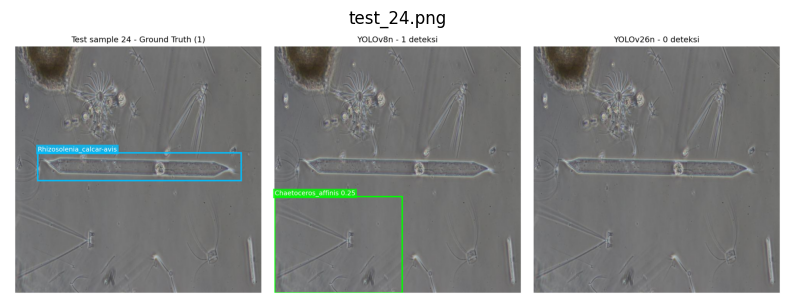

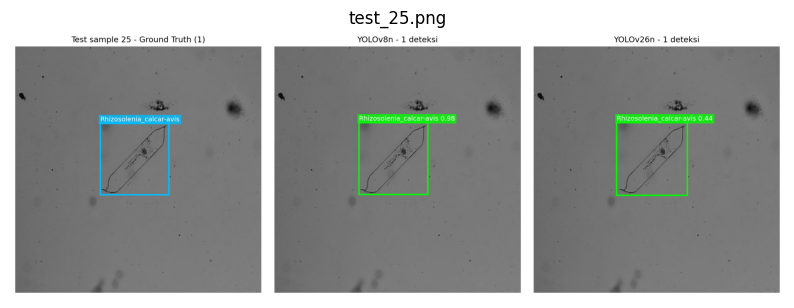

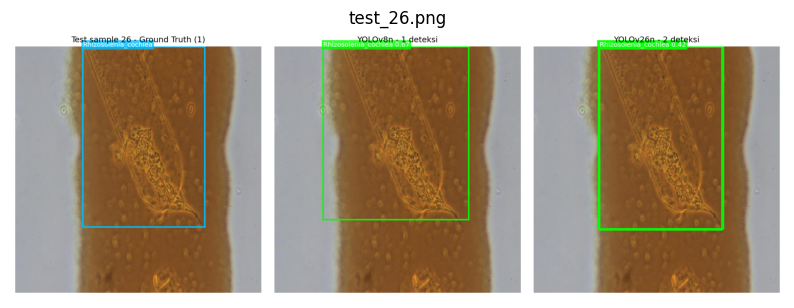

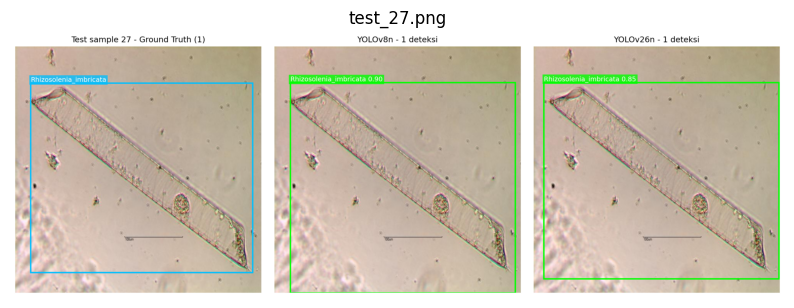

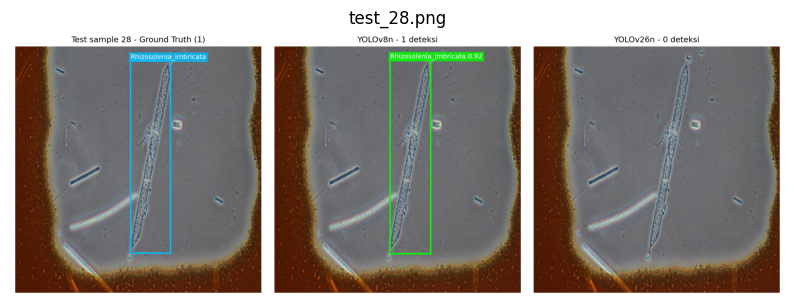

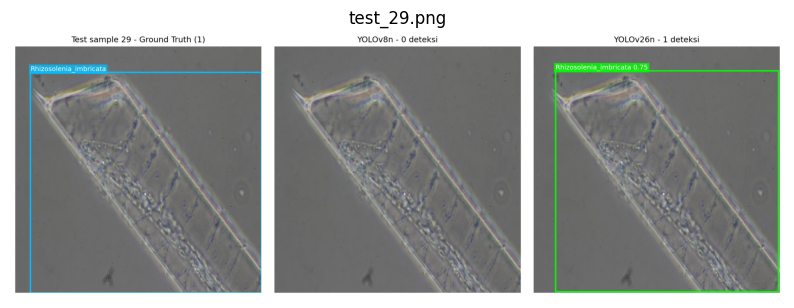

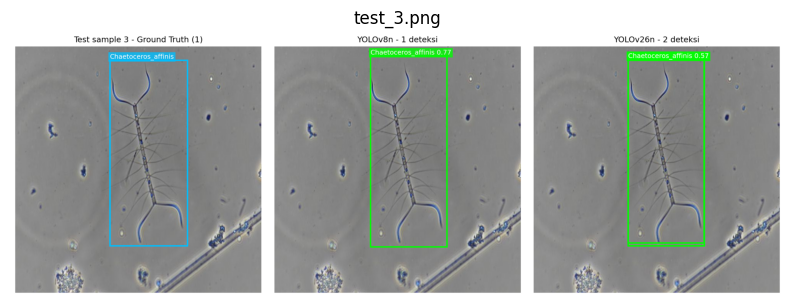

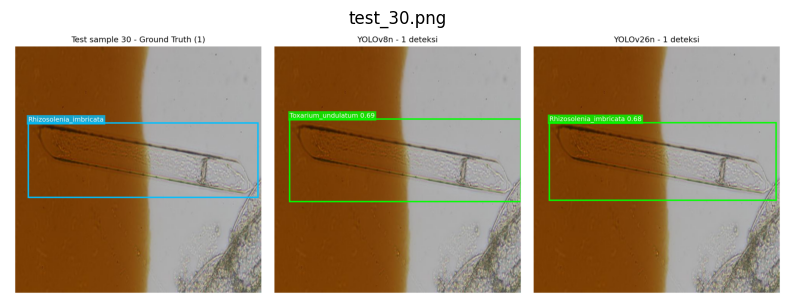

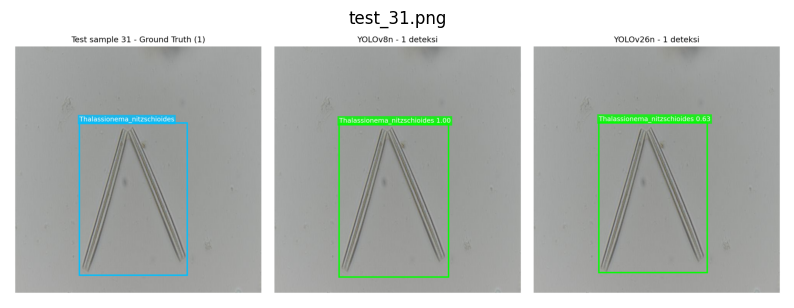

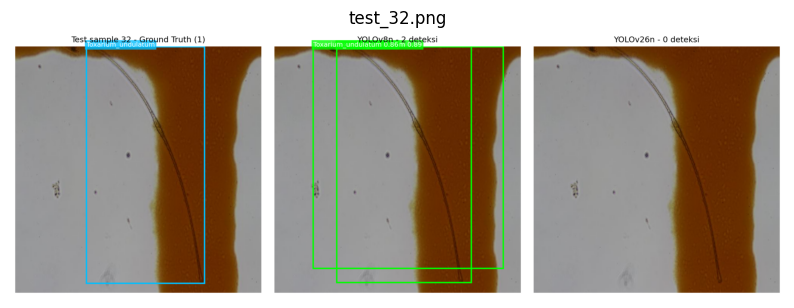

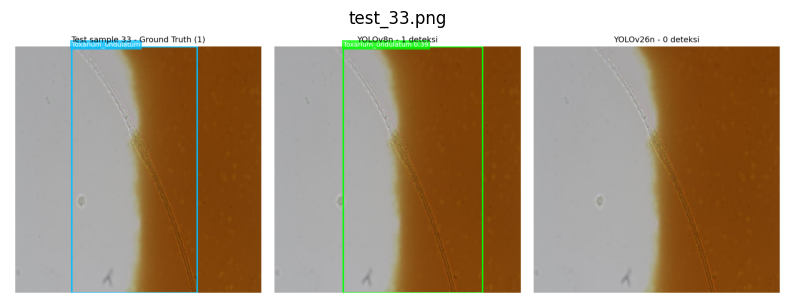

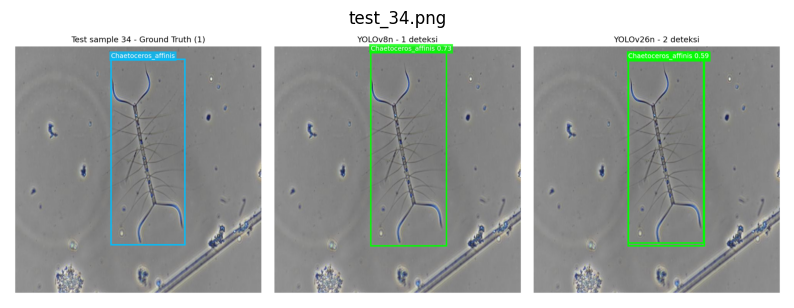

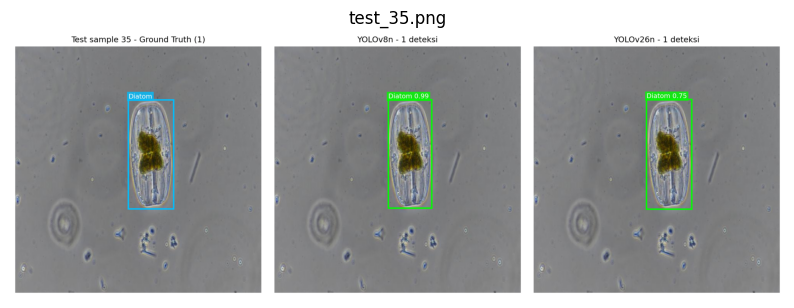

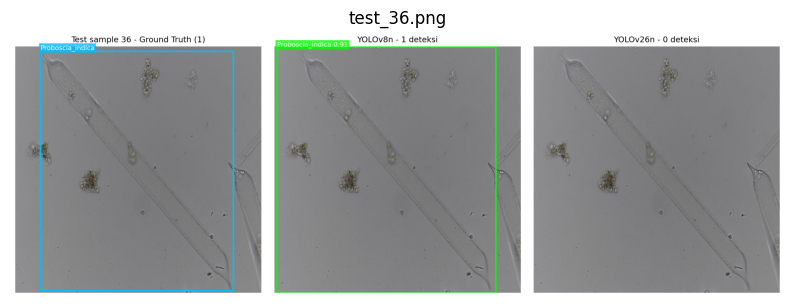

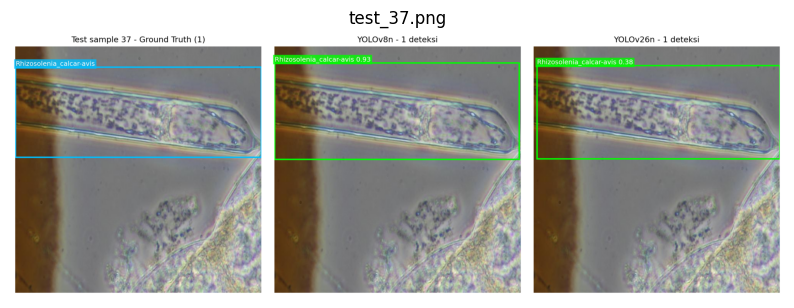

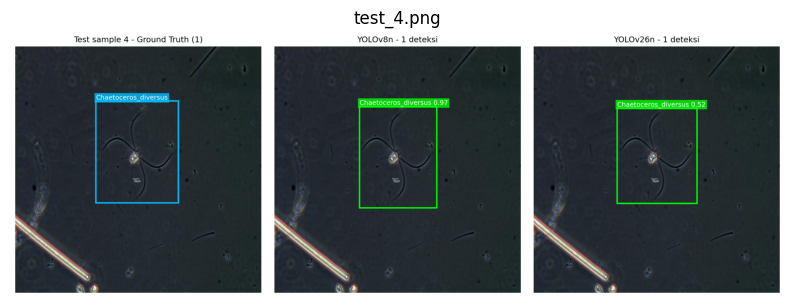

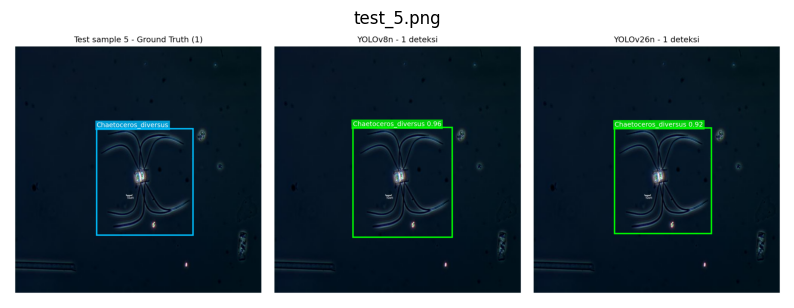

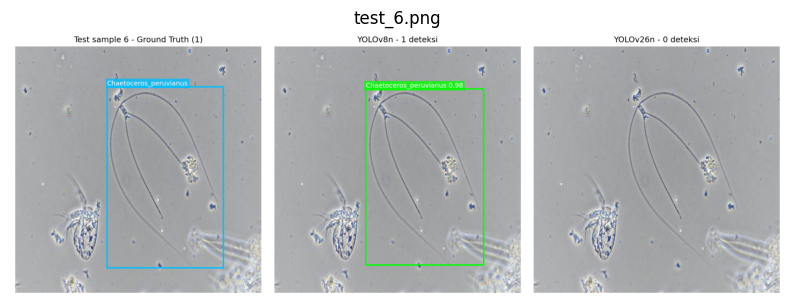

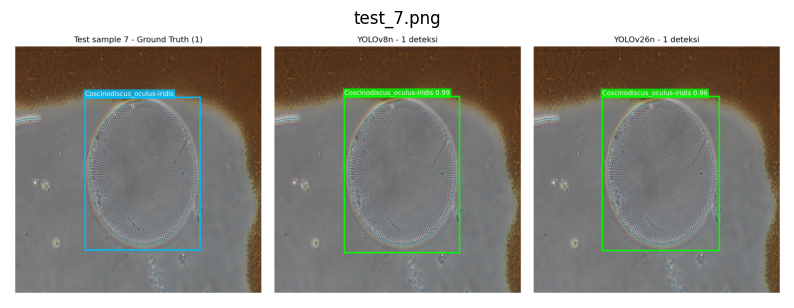

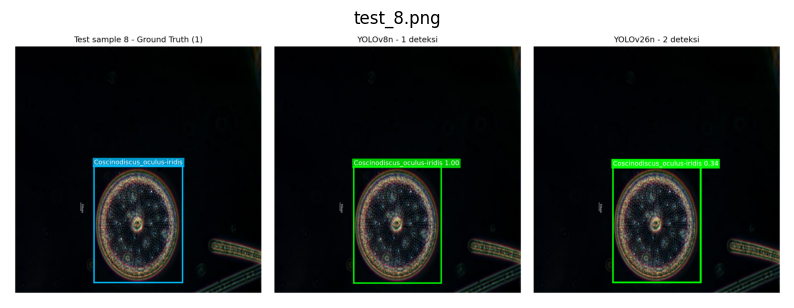

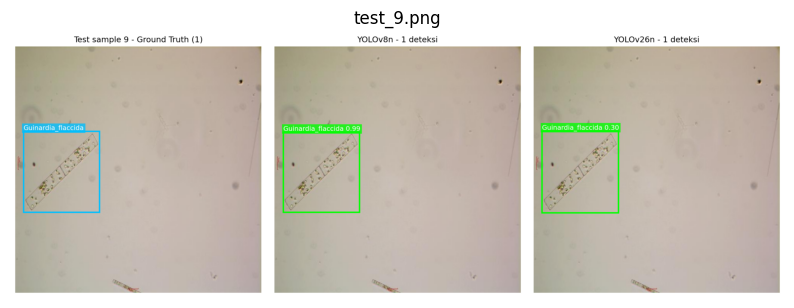


Selesai menampilkan semua gambar visualisasi.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Pastikan individual_dir sudah didefinisikan dari sel sebelumnya
# Jika belum, uncomment baris di bawah ini dan sesuaikan Path jika perlu
# from pathlib import Path
# OUTPUT_DIR = Path('outputs_yolo/test_visualizations') # Sesuaikan jika berbeda
# individual_dir = OUTPUT_DIR / "individual"

if 'individual_dir' not in locals():
    print("Variabel 'individual_dir' tidak ditemukan. Harap jalankan sel sebelumnya atau definisikan ulang.")
else:
    print(f"\nMenampilkan visualisasi dari: {individual_dir}")
    image_files = sorted(individual_dir.glob("test_*.png")) # Mengurutkan berdasarkan nama 'test_1.png', 'test_2.png'

    if not image_files:
        print("Tidak ada gambar visualisasi ditemukan di direktori yang ditentukan.")
    else:
        for img_path in image_files:
            try:
                img = Image.open(img_path)
                fig, ax = plt.subplots(figsize=(10, 10)) # Ukuran disesuaikan
                ax.imshow(img)
                ax.set_title(img_path.name) # Judul gambar adalah nama filenya
                ax.axis('off')
                plt.show()
                plt.close(fig)
            except Exception as e:
                print(f"Gagal menampilkan {img_path.name}: {e}")
        print("\nSelesai menampilkan semua gambar visualisasi.")